# PCA — An Illustrated Tour

> Find the **directions of greatest variance** in your data. Project everything onto the first few of these directions to compress, denoise, and visualise.

---

**What we cover:**
- The objective — maximise variance / minimise reconstruction error
- Eigenvectors of the covariance matrix as principal axes
- The 2-D rotation picture — see PC1 and PC2 as arrows
- Scree plot and explained variance
- Reconstruction quality on digits as $k$ grows
- PCA as a denoiser and as a visualiser of high-D data

## The picture — principal axes = directions of maximum variance

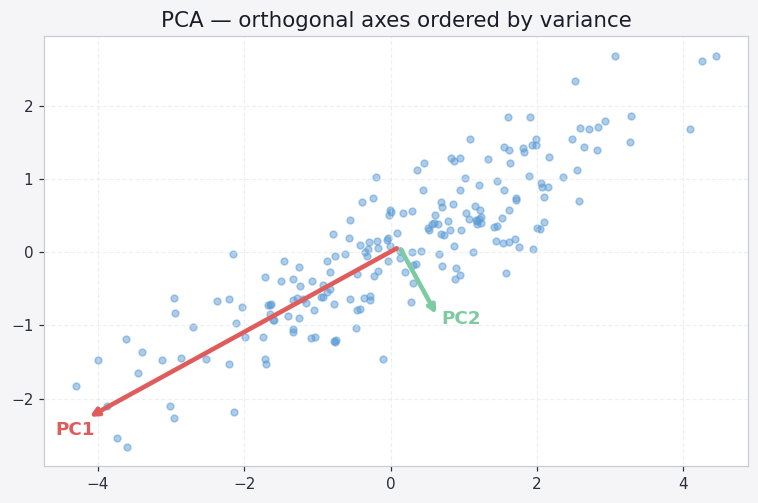

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
X = rng.multivariate_normal([0,0], [[3,1.5],[1.5,1]], 200)
mu = X.mean(0); cov = np.cov(X.T)
vals, vecs = np.linalg.eigh(cov)
order = np.argsort(vals)[::-1]; vals, vecs = vals[order], vecs[:, order]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:,0], X[:,1], s=20, color=P[0], alpha=0.5)
for i, c in enumerate([P[1], P[3]]):
    v = vecs[:, i] * 2.5 * np.sqrt(vals[i])
    ax.annotate('', xy=mu+v, xytext=mu,
                arrowprops=dict(arrowstyle='->', color=c, lw=3))
    ax.text(*(mu+1.1*v), f'PC{i+1}', color=c, fontsize=12, weight='bold')
ax.set_aspect('equal'); ax.set_title('PCA — orthogonal axes ordered by variance')
ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits, load_iris

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

rng = np.random.default_rng(0)
n = 300
z = rng.standard_normal(n)
noise = rng.standard_normal((n, 2)) * 0.4
X = np.column_stack([3*z + 2, 1.5*z + 1]) + noise   # roughly along (3, 1.5)
X = X - X.mean(0)
print('Toy 2-D data:', X.shape)

Toy 2-D data: (300, 2)


---
## Objective — Variance Captured by a Direction

Let $u \in \mathbb{R}^d$ with $\|u\| = 1$. The variance of the data projected on $u$ is

$$\operatorname{Var}\bigl(u^T x\bigr) = u^T \Sigma\, u, \qquad \Sigma = \tfrac{1}{m}\sum_i x_i x_i^T.$$

Maximising over the unit sphere yields

$$u_1 = \arg\max_{\|u\|=1} u^T \Sigma\, u = \text{top eigenvector of } \Sigma.$$

Subsequent components are eigenvectors orthogonal to the previous ones. Equivalently, PCA **minimises the squared reconstruction error** when projecting onto $k$ directions.

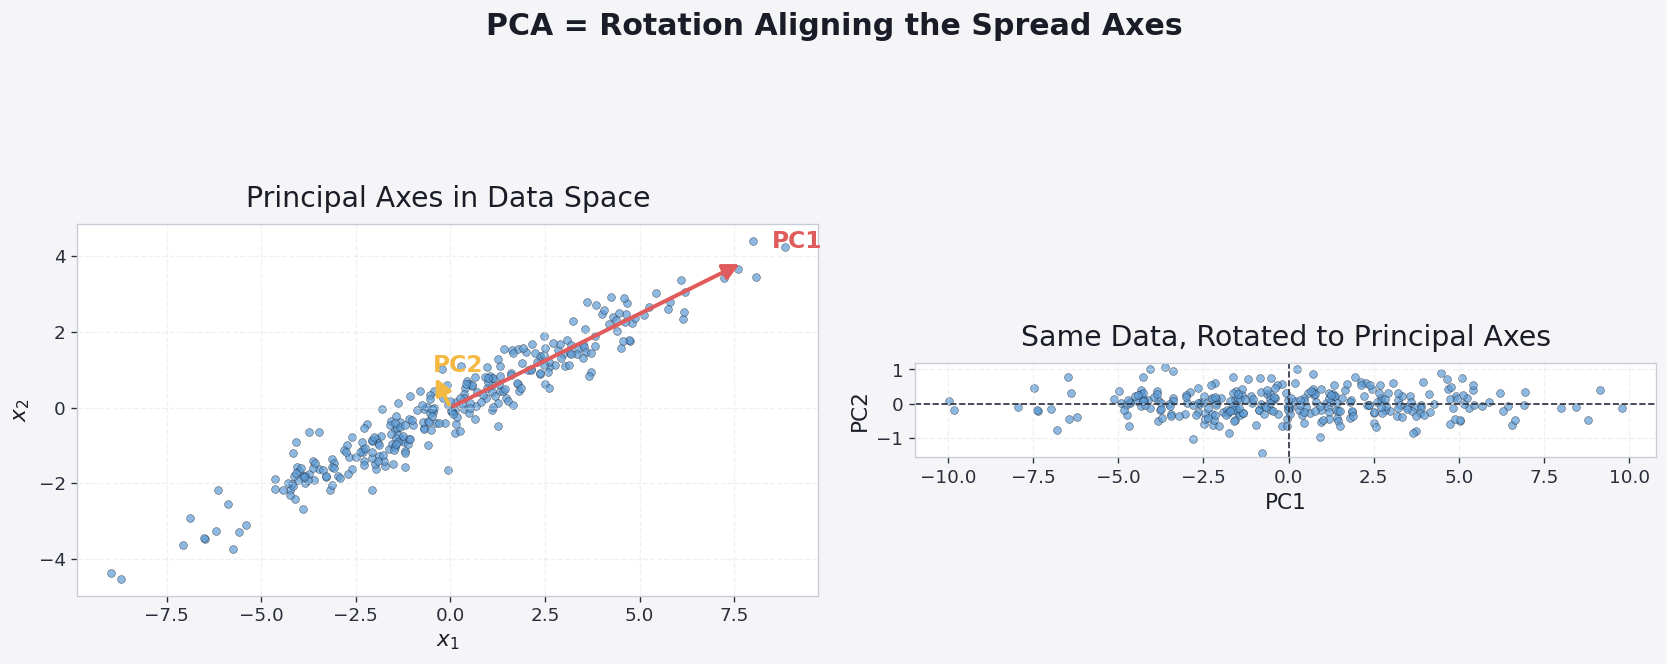

In [3]:
pca = PCA(n_components=2).fit(X)
components = pca.components_
lengths    = np.sqrt(pca.explained_variance_) * 2.5

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.scatter(X[:,0], X[:,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.7)
for vec, length, col, name in zip(components, lengths, [C1, CB], ['PC1', 'PC2']):
    arr = FancyArrowPatch((0,0), (vec[0]*length, vec[1]*length),
                          arrowstyle='-|>', mutation_scale=20, color=col, lw=2.4, zorder=6)
    ax.add_patch(arr)
    ax.text(vec[0]*length*1.1, vec[1]*length*1.1, name,
            color=col, fontsize=14, fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Principal Axes in Data Space', pad=10)
ax.set_aspect('equal'); ax.grid(True)

ax = axes[1]
Z = pca.transform(X)
ax.scatter(Z[:,0], Z[:,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.7)
ax.axhline(0, color='#2a2e3a', ls='--', lw=1)
ax.axvline(0, color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Same Data, Rotated to Principal Axes', pad=10)
ax.set_aspect('equal'); ax.grid(True)
fig.suptitle('PCA = Rotation Aligning the Spread Axes', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Scree Plot — How Many Components?

On the digits dataset (64 pixels per image), PCA orders directions by variance explained. The **scree plot** shows that the first 10–20 components capture most of the signal, and components beyond ~50 capture noise.

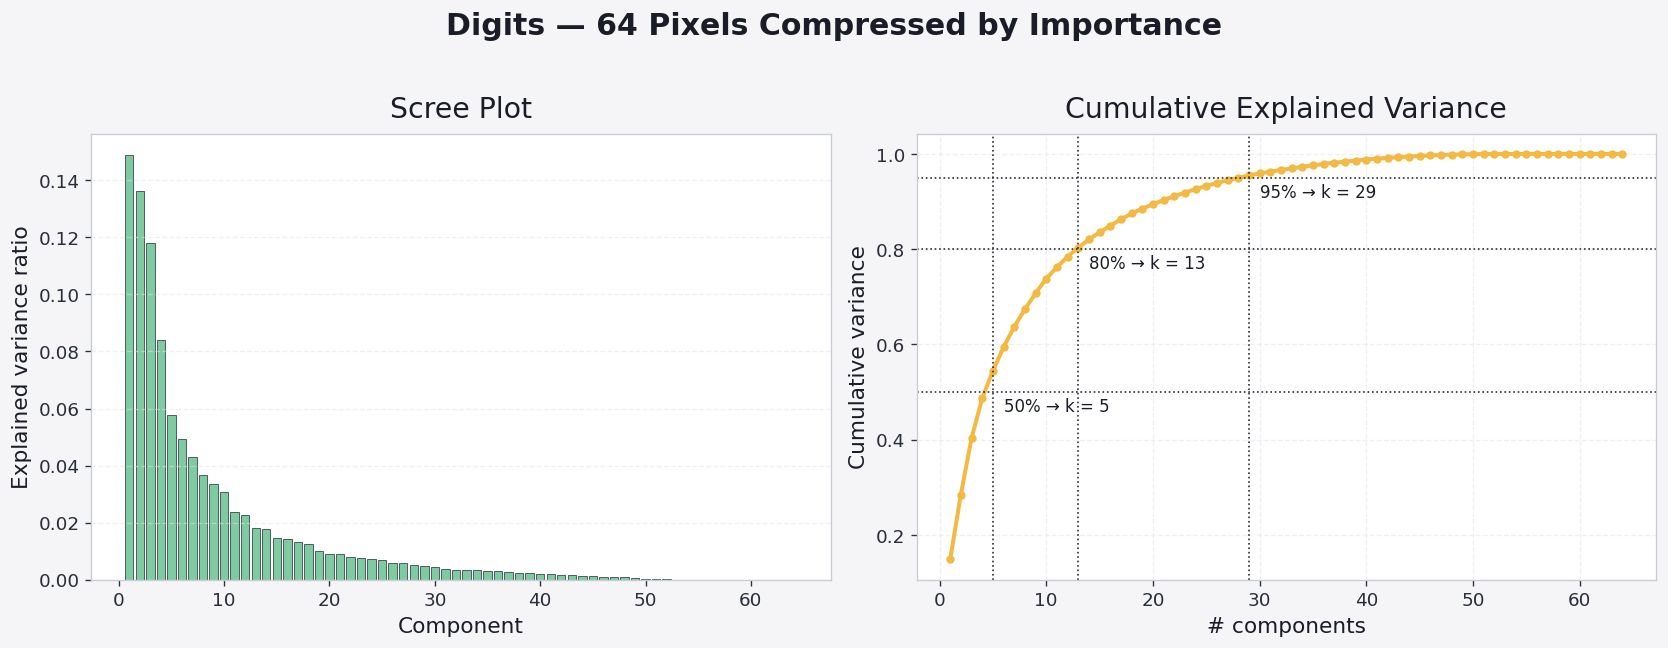

In [4]:
digits = load_digits()
Xd = digits.data    # (1797, 64)
yd = digits.target
Xd = Xd - Xd.mean(0)
pca_d = PCA().fit(Xd)
ev = pca_d.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ax = axes[0]
ax.bar(np.arange(1, 65), ev, color=CM, edgecolor='#1a1d27', lw=0.4)
ax.set_xlabel('Component'); ax.set_ylabel('Explained variance ratio')
ax.set_title('Scree Plot', pad=10); ax.grid(True, axis='y')

ax = axes[1]
ax.plot(np.arange(1, 65), np.cumsum(ev), color=CB, lw=2.4, marker='o', ms=4)
for thr in [0.50, 0.80, 0.95]:
    n_thr = int(np.searchsorted(np.cumsum(ev), thr) + 1)
    ax.axhline(thr, color='#2a2e3a', ls=':', lw=1)
    ax.axvline(n_thr, color='#2a2e3a', ls=':', lw=1)
    ax.annotate(f'{int(thr*100)}% → k = {n_thr}', xy=(n_thr+1, thr-0.04),
                fontsize=10, color='#1a1d27')
ax.set_xlabel('# components'); ax.set_ylabel('Cumulative variance')
ax.set_title('Cumulative Explained Variance', pad=10); ax.grid(True)
fig.suptitle('Digits — 64 Pixels Compressed by Importance', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

---
## Reconstruction — What $k$ Components Are Worth

Project onto the top $k$ components, then project back. Even with $k$ much smaller than 64 the reconstructed digits are still recognisable.

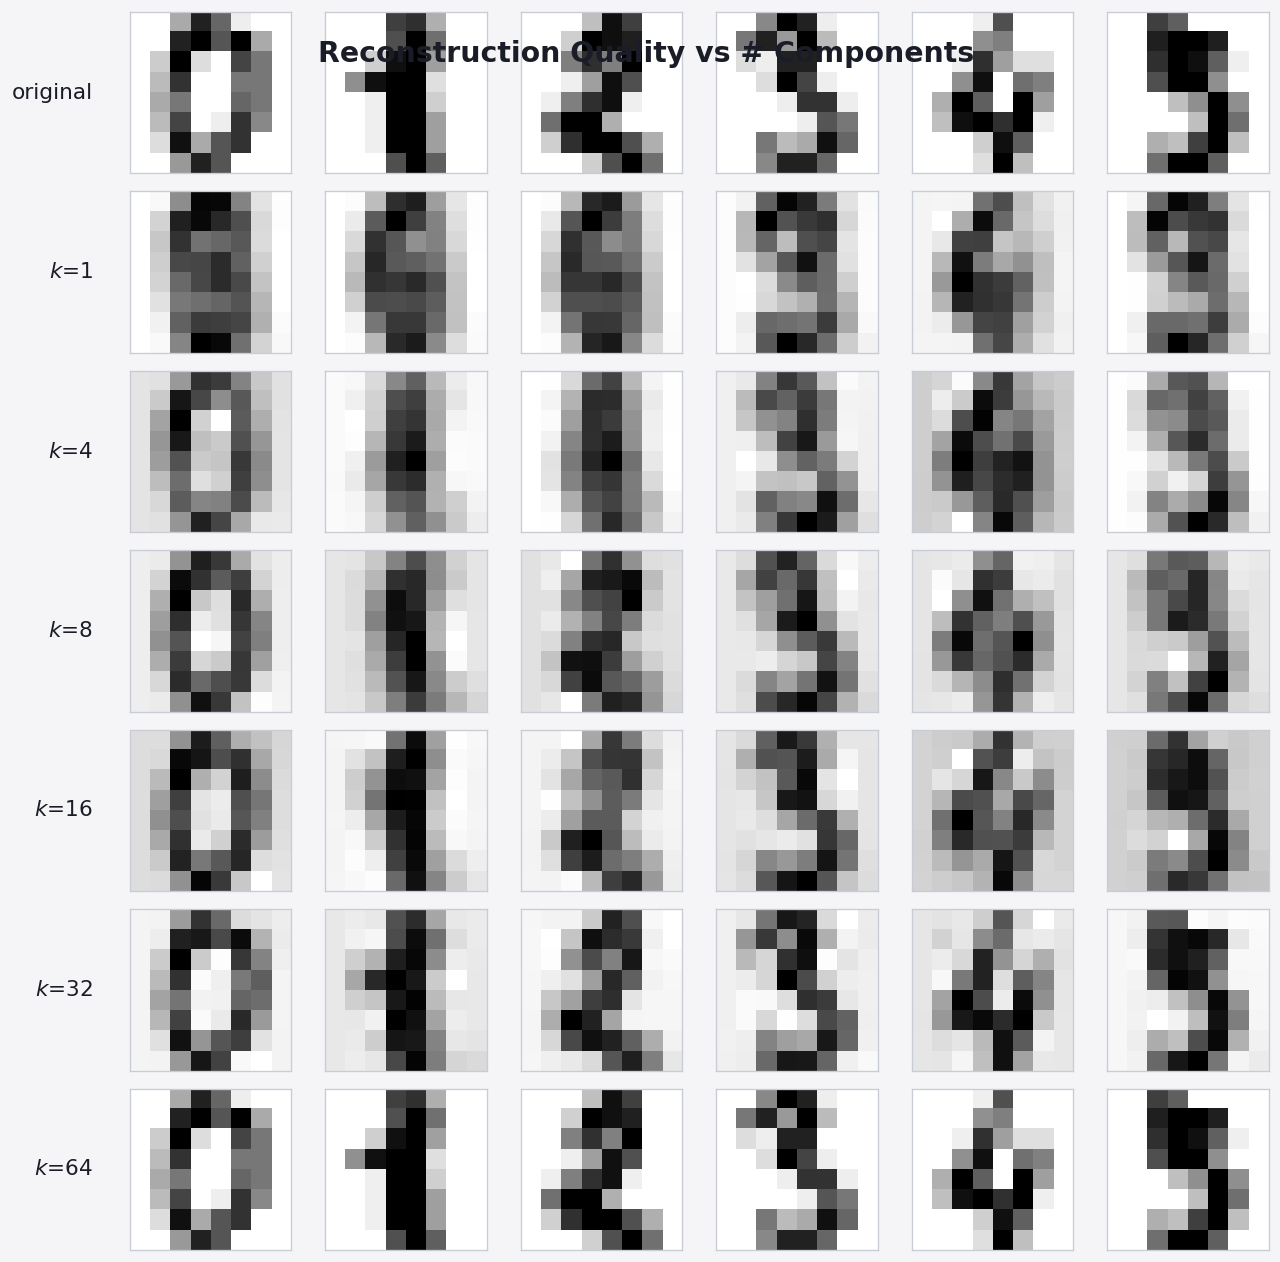

In [5]:
ks = [1, 4, 8, 16, 32, 64]
n_show = 6
samples = digits.images[:n_show]
centroid = digits.data.mean(0)
fig, axes = plt.subplots(len(ks)+1, n_show, figsize=(11, 11))
for j, img in enumerate(samples):
    axes[0, j].imshow(img, cmap='gray_r')
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    if j == 0: axes[0, j].set_ylabel('original', rotation=0, ha='right', va='center', labelpad=22, color='#1a1d27')

for r, k in enumerate(ks, start=1):
    p = PCA(n_components=k).fit(digits.data)
    rec = p.inverse_transform(p.transform(digits.data[:n_show]))
    for j in range(n_show):
        axes[r, j].imshow(rec[j].reshape(8, 8), cmap='gray_r')
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
    axes[r, 0].set_ylabel(f'$k$={k}', rotation=0, ha='right', va='center', labelpad=22, color='#1a1d27')
fig.suptitle('Reconstruction Quality vs # Components', fontsize=17, fontweight='bold', y=0.93)
plt.tight_layout(); plt.show()

---
## PCA for Visualisation — Iris in 2-D

Project a 4-D dataset (Iris) onto its top 2 PCs to **see** class structure that no single feature reveals.

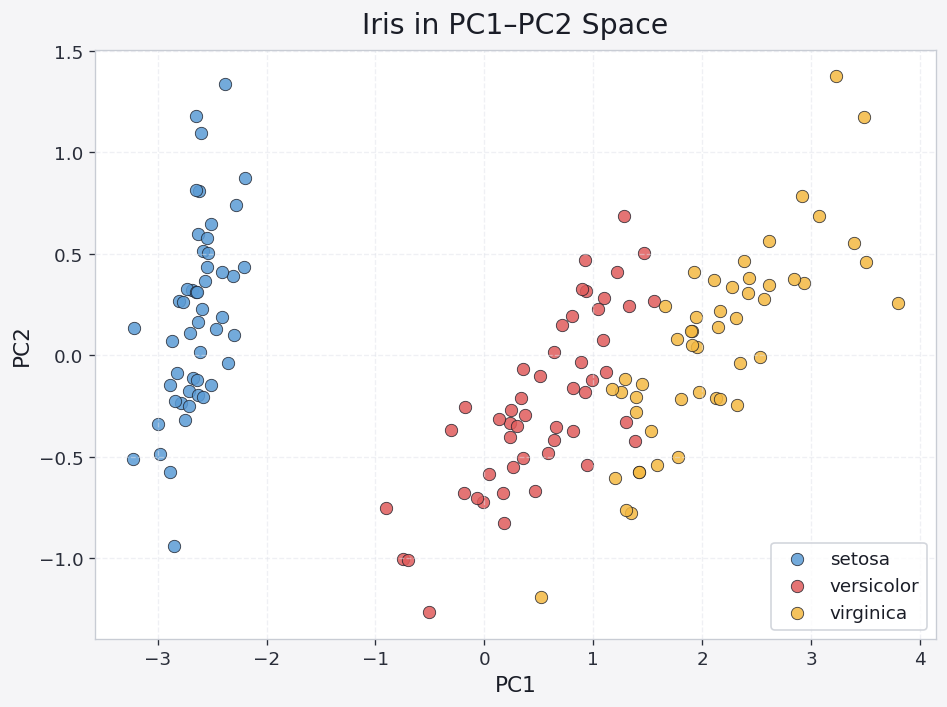

In [6]:
iris = load_iris()
Xi = iris.data - iris.data.mean(0)
yi = iris.target
Zi = PCA(n_components=2).fit_transform(Xi)
names = iris.target_names

fig, ax = plt.subplots(figsize=(8, 6))
for k, col in zip([0,1,2], [C0, C1, CB]):
    m = yi == k
    ax.scatter(Zi[m,0], Zi[m,1], c=col, s=55, edgecolors='#1a1d27', lw=0.5, alpha=0.85, label=names[k])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Iris in PC1–PC2 Space', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use PCA — and when not to

| Situation | PCA | t-SNE / UMAP | Autoencoder | Random projection |
|---|---|---|---|---|
| Linear structure, want global geometry | ✅ | ❌ distorts | partial | partial |
| Visualise non-linear clusters | ❌ | ✅ | partial | ❌ |
| Need exact inverse | ✅ orthogonal | ❌ | ✅ | ✅ |
| $d > 10\,000$ but linear OK | ✅ via SVD / random PCA | ❌ slow | partial | ✅ very fast |

> PCA is the right first move when you want to **denoise**, **decorrelate** or **compress** before downstream modelling.


---
## 🎯 Try this

1. **Scree plot.** Plot eigenvalues sorted decreasing — pick the smallest $k$ that captures 90% variance. Compare to the elbow visually.
2. **Whitening.** Divide each component by its standard deviation. Downstream models (especially KNN, SVM) often improve.
3. **Robust PCA.** Replace one row with a huge outlier — PCA's first axis snaps toward it. Try `RobustPCA` from `sklearn.decomposition` and observe stability.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Centring | Subtract the mean | PCA is about variance around the centroid |
| Covariance $\Sigma$ | $\tfrac{1}{m}X^T X$ | Encodes pairwise spread |
| Principal components | Eigenvectors of $\Sigma$ | Orthogonal directions, sorted by eigenvalue |
| Explained variance | $\lambda_k / \sum_j \lambda_j$ | Tells you how much each PC matters |
| Reconstruction | $X \approx Z V^T$ with first $k$ PCs | Best rank-$k$ approximation in Frobenius norm |
| Strength | Linear, fast, deterministic | Great pre-processing for many models |
| Weakness | Linear only; sensitive to scale | Standardise features first; use kernel PCA / t-SNE / UMAP for non-linear |

**Bottom line:** PCA is **rotation by importance**. It turns a noisy high-dimensional dataset into a small set of directions that explain almost all the variance — the ideal first lens before any other modelling.